#### Question 1 ####

Grâce à la base de données XCOM du NIST (http://physics.nist.gov/PhysRefData/Xcom/html/xcom1.html), le l'atténuation total pour 60 keV dans l'eau est de 0.2059 $cm^2/g$ ce qui donne pour densité de 1 g / $cm^3$ un $\mu$ de 0.2059/cm.

In [9]:
import numpy as np

mu = 0.2059 #/cm
I_0 = 60 #keV
x_5 = 5 #cm
x_20 = 20 #cm

def ration_output_input_intensity(x):
    return np.e**(-mu*x)

print(f'Fraction signal après 5 cm: {ration_output_input_intensity(x_5):.5f}')
print(f'Fraction signal après 20 cm: {ration_output_input_intensity(x_20):.5f}')

Fraction signal après 5 cm: 0.35719
Fraction signal après 20 cm: 0.01628


#### Question 2 ####

Dans cette étape, on implémente l'algorithme de rétroprojection simple par la fonction laminogram() afin de reconstruire une image brute à partir du sinogramme. L'approche est de type « voxel-driven ». Pour chaque angle d'acquisition contenu dans les données lues par la fonction readInput(), on calcule la position de chaque voxel de la grille sur le détecteur en utilisant $S = X \cos\theta + Y \sin\theta$. Les valeurs du sinogramme correspondant à ces positions sont ensuite accumulées dans une matrice d'image initialement vide. Puisqu'il s'agit d'une rétroprojection non filtrée, chaque point de l'objet est « étalé » sur toute la grille de reconstruction selon les angles de vue, ce qui génère une image présentant un flou inversement proportionnel à la distance au centre ($1/r$). Le code utilise numpy.meshgrid pour optimiser les calculs sur l'ensemble de la grille de voxels. Les dimensions et la résolution sont définies dans le module de géométrie. Le code utilisé est le suivant :

In [ ]:
def laminogram():
    
    [nbprj, angles, sinogram] = readInput()

    # initialiser une image reconstruite
    image = np.zeros((geo.nbvox, geo.nbvox))

    # "etaler" les projections sur l'image
    # ceci sera fait de façon "voxel-driven"
    # pour chaque voxel, trouver la contribution du signal reçu
    # voxel‑driven laminogram
    # paramètres du détecteur
    L = geo.nbpix * geo.voxsize          # largeur physique du détecteur
    tmin = -L/2                           # début du détecteur
    dt = L / geo.nbpix                    # taille d’un pixel détecteur

    for j in range(geo.nbvox):            # boucle colonnes
        print(f"working on image column: {j+1}/{geo.nbvox}")
        x =  (j - geo.nbvox/2 + 0.5) * geo.voxsize   # coordonnée x du voxel

        for i in range(geo.nbvox):        # boucle lignes
            y = (i - geo.nbvox/2 + 0.5) * geo.voxsize   # coordonnée y du voxel
            total = 0.0                   # accumulation des contributions

            for a, th in enumerate(angles):           # boucle angles
                s = x*np.cos(th) + y*np.sin(th)       # projection du voxel sur le détecteur
                k = int(round((s - tmin) / dt))       # conversion en index détecteur

                if 0 <= k < geo.nbpix:                # si dans les bornes
                    total += sinogram[a, k]           # ajouter la valeur du sinogramme

            image[i, j] = total           # assigner la valeur finale du voxel
            

    image = np.fliplr(image) # mettre l'image à l'endroit
    util.saveImage(image, "laminogram_fantome_192_04_image_droite_test_question3")

On roule le code et on obtient l'image suivante du "password".

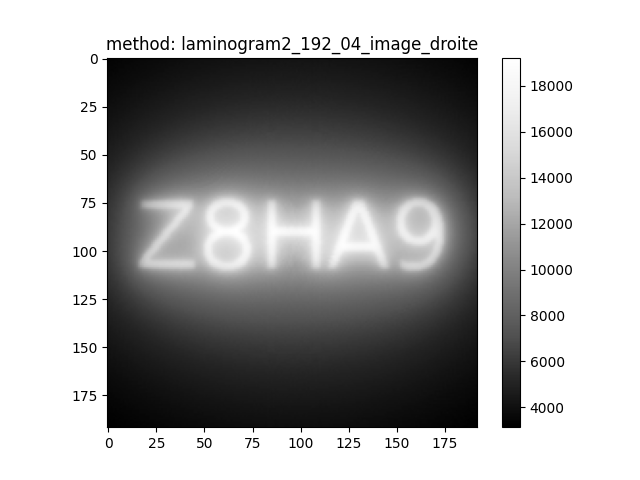

L'image reconstruite est dominée par un halo diffus qui masque les détails de l'objet. Ce phénomène s'explique par le fait que la rétroprojection simple « étale » les mesures du détecteur sur toute la longueur du trajet des rayons sans correction supplémentaire. Cette accumulation sous tous les angles entraîne une superposition d'informations au centre de l'image, ce qui crée un flou en 1/r.

#### Question 3 ####

Pour corriger le flou en $1/r$ observé précédemment, on introduit une étape de filtrage sur le sinogramme avant de procéder à la rétroprojection. Cette opération est réalisée par la fonction CTfilter.filterSinogram(), qui applique un filtre Ram-Lak dans le domaine fréquentiel. Puisque la rétroprojection simple amplifie artificiellement les basses fréquences (le centre du domaine de Fourier), le filtre rampe pondère chaque projection pour atténuer ces basses fréquences et amplifier les hautes fréquences. Cela permet de restaurer les contrastes et les détails fins de l'objet. On utilise cette ligne de code à la fin de laminogram() :

In [ ]:
CTfilter.filterSinogram(image)

Cette ligne renvoit au fichier CTfiltre.py suivant:

In [ ]:
import numpy as np

## filtrer le sinogramme
## ligne par ligne
def filterSinogram(sinogram):
    for i in range(sinogram.shape[0]):
        sinogram[i] = filterLine(sinogram[i])

## filter une ligne (projection) via FFT
def filterLine(projection):

    # FFT de la projection
    P = np.fft.fft(projection)

    # fréquences associées à chaque coefficient FFT
    freqs = np.fft.fftfreq(len(projection))

    # filtre passe-haut demandé : |u|
    H = np.abs(freqs)

    # appliquer le filtre dans le domaine fréquentiel
    Pf = P * H

    # retour dans le domaine spatial (partie réelle)
    filtered = np.fft.ifft(Pf).real

    return filtered



On roule le code et on peut comparer le résultat à l'image non filtrée. On peut voir, en haut, l'image non filtrée, puis, en bas, l'image filtrée. On zoome pour mieux voir les différences.

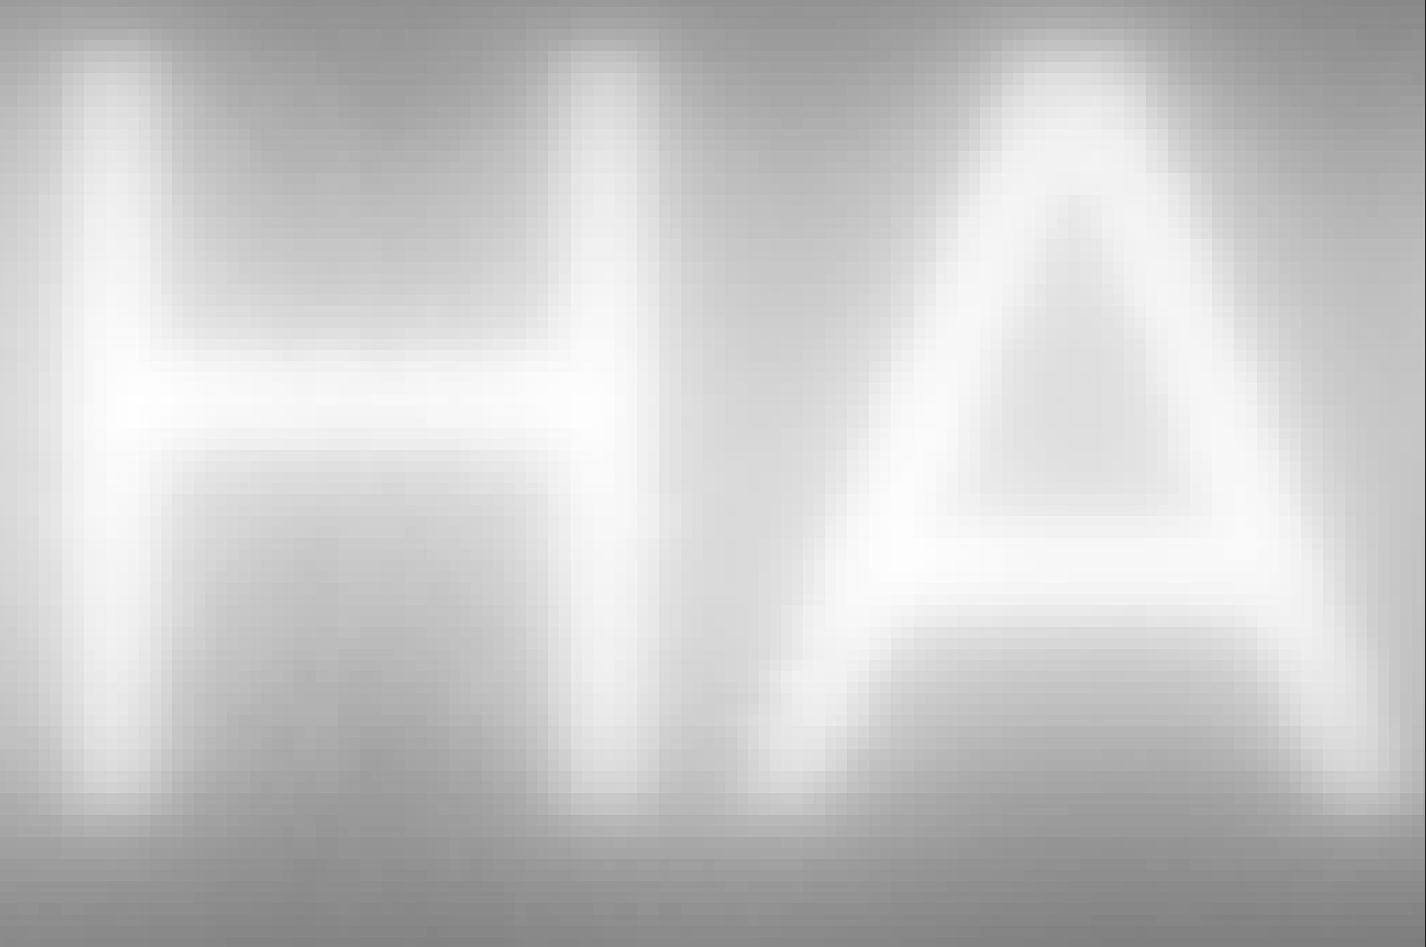
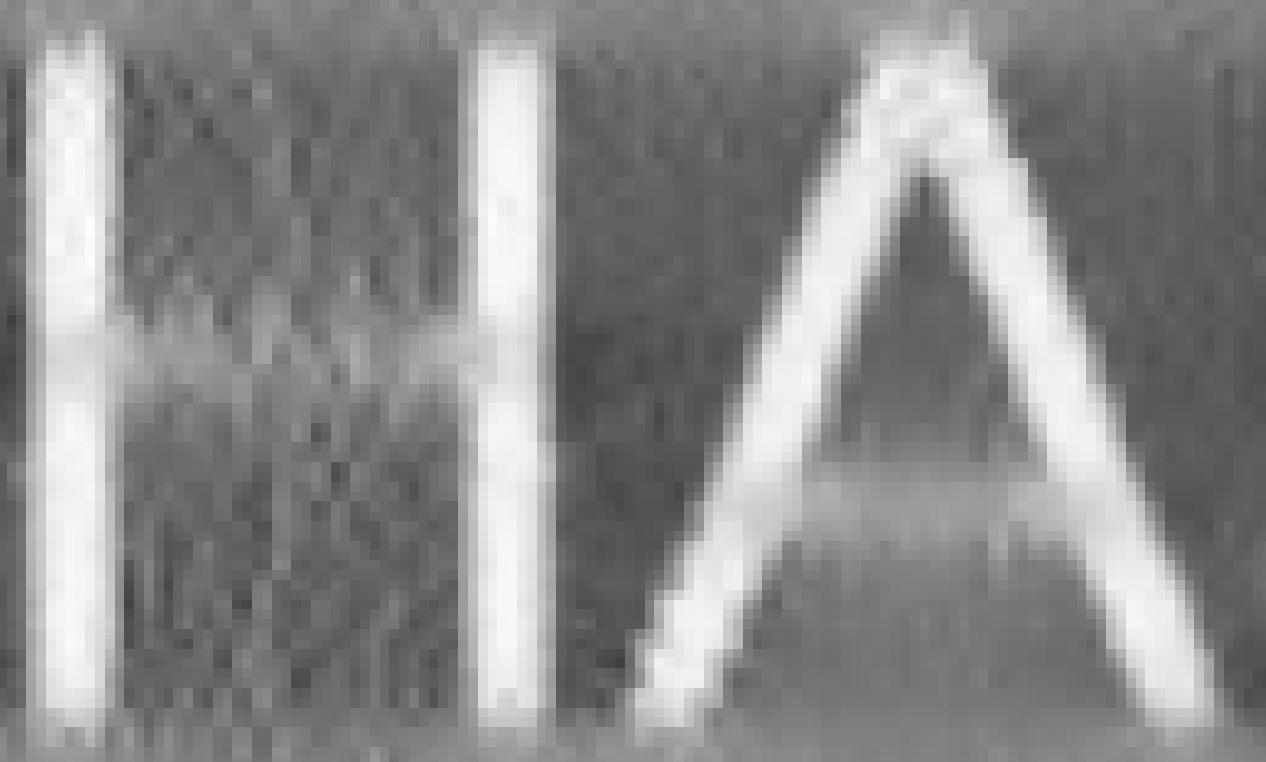

Sur le sinogramme filtré, on remarque que les contours sont beaucoup plus nets et l'effet de halo est moins présent.

#### Question 4 ####

Pour cette question, on combine les étapes précédentes pour établir l'algorithme de rétroprojection filtrée par la fonction backproject(). Le processus se déroule en deux étapes. D'abord, le sinogramme est traité avec le filtre rampe pour éliminer les basses fréquences excédentaires, puis ces projections filtrées sont rétroprojetées sur la grille d'image. Pour cette question, la valeur de chaque voxel est déterminée en sélectionnant le pixel du détecteur le plus proche de la coordonnée calculée (méthode "nearest neighbor"). On a le code suivant :

In [ ]:
def backproject():

    [nbprj, angles, sinogram] = readInput()

    # filtrer le sinogramme (question 3)
    CTfilter.filterSinogram(sinogram)

    # initialiser une image reconstruite
    image = np.zeros((geo.nbvox, geo.nbvox))

    # paramètres du détecteur
    L = geo.nbpix * geo.voxsize      # largeur physique du détecteur
    tmin = -L/2                       # début du détecteur
    dt = L / geo.nbpix                # taille d’un pixel détecteur

    # rétroprojection filtrée voxel-driven

    # --- grille des voxels ---
    coords = (np.arange(geo.nbvox) - geo.nbvox/2 + 0.5) * geo.voxsize
    X, Y = np.meshgrid(coords, coords)

    image = np.zeros((geo.nbvox, geo.nbvox))

    for a, th in enumerate(angles):

        cos_th = np.cos(th)
        sin_th = np.sin(th)

        # projection de tous les voxels
        S = X * cos_th + Y * sin_th

        Kfloat = (S - tmin) / dt

        K1 = np.floor(Kfloat).astype(int)
        K2 = np.ceil(Kfloat).astype(int)

        # choix du plus proche (équivalent à ton if abs(...))
        choose_k1 = np.abs(K1 - Kfloat) <= np.abs(K2 - Kfloat)
        K = np.where(choose_k1, K1, K2)

        # masque validité détecteur
        valid = (K >= 0) & (K < geo.nbpix)

        # accumulation
        image[valid] += sinogram[a, K[valid]]

    # remettre l'image à l'endroit
    image = np.fliplr(image)

    util.saveImage(image, "fbp")

On run et on obtient les images suivantes: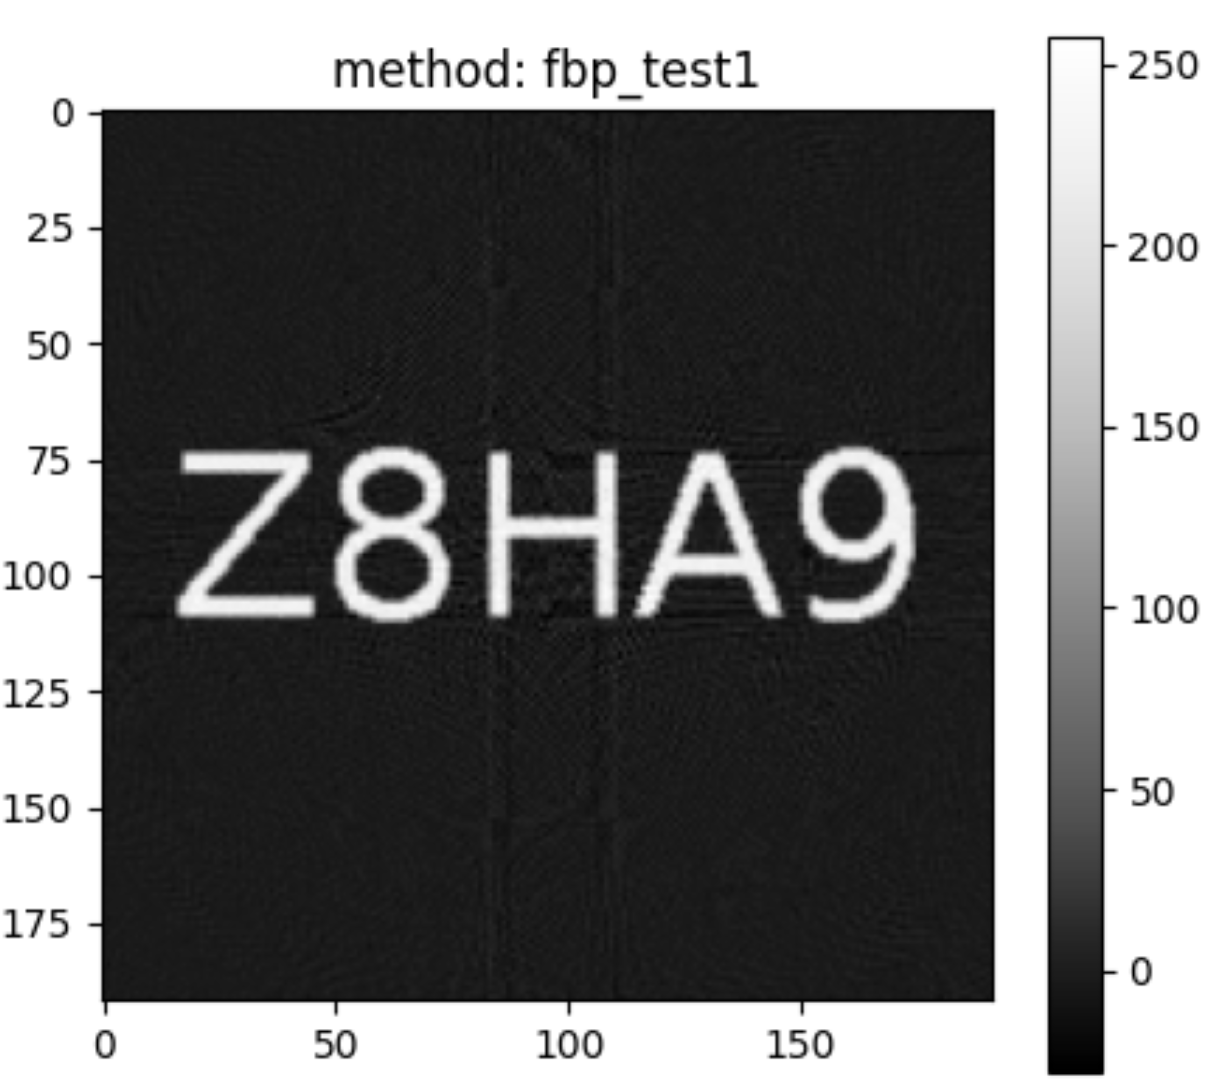, 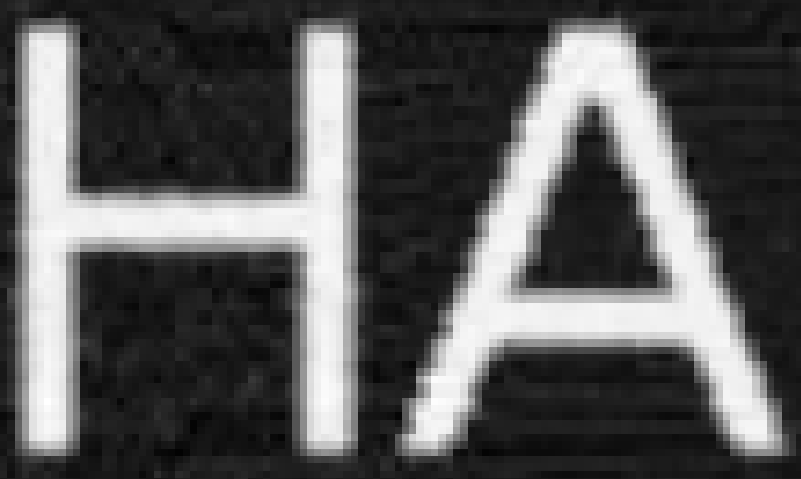

Le changement est très grand. Le halo diffus en $1/r$ a complètement disparu. On a donc une image aux contours nets et aux structures bien définies. En filtrant les données avant de les étaler sur la grille, on a neutralisé la superposition artificielle au centre de l'image. On remarque cependant que l'image n'est pas encore parfaite, puisqu'il y a beaucoup de bruit en arrière-plan.

#### Question 5 - Amélioration de la qualitée de l'image

Pour améliorer davantage la qualité de la reconstruction, on optimise l'algorithme dans la fonction backproject2() en remplaçant la sélection du "pixel le plus proche" par une interpolation linéaire. Puisque la projection d'un voxel $S = X \cos\theta + Y \sin\theta$ tombe rarement pile au centre d'un pixel du détecteur, l'interpolation permet d'estimer la valeur exacte du signal en pondérant les contributions des deux pixels adjacents.

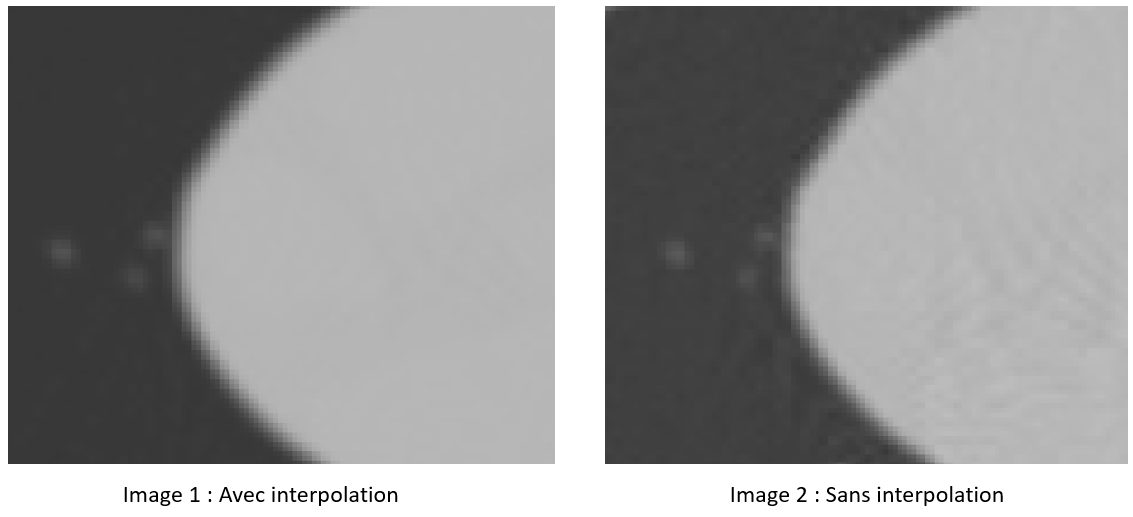

En interpolant plutôt qu’en utilisant la méthode du plus proche voisin, on observe que l’image obtenue est plus uniforme. Le temps de calcul avec interpolation est de 1.21 secondes, contre 1.52 secondes pour la méthode sans interpolation. Cette différence de temps est surprenante, étant donné que la méthode avec interpolation exécute davantage de lignes de code que celle sans interpolation.

Face à ce résultat inattendu, des tests supplémentaires ont été effectués. Puisque la méthode utilisant l’interpolation ne faisait pas appel à la fonction "round", une première hypothèse a été formulée : cette fonction pourrait être responsable d’un temps d’exécution plus élevé. Elle a donc été remplacée par une fonction plus simple du module math, soit "math.ceil", qui arrondit à l’entier supérieur. En utilisant cette fonction, le temps d’exécution est passé à seulement 0.86 secondes (bien que l'image soit différente). Cela confirme que la fonction "math.ceil" est plus rapide que la fonction round.

Un dernier test a été réalisé afin d’obtenir un résultat identique à celui produit par la fonction "round", mais en utilisant plutôt les fonctions "math.floor" et "math.ceil". Cette approche ajoute plusieurs lignes de code, mais le temps de calcul obtenu est de 0.74 secondes, ce qui est plus rapide que celui de la méthode avec interpolation.

In [ ]:
#index trouvé avec round
k = int(round((s - tmin) / dt))     

#index trouvé avec math.ceil et math.floor
k1 = int(mt.floor((s - tmin) / dt))
k2 = int(mt.ceil((s - tmin) / dt))     
if(abs(k1-((s - tmin) / dt)))<=(abs(k2-((s - tmin) / dt))):
    k = k1
else:
    k = k2

if 0 <= k < geo.nbpix:
    total += sinogram[a, k]        

#Interpolation au lieu du plus proche voisin
k = (s - tmin) / dt
k1 = int(mt.floor((s - tmin) / dt))     
k2 = int(mt.ceil((s - tmin) / dt))

if (0 <= k1 < geo.nbpix) and (k2 != k1):
    total += sinogram[a, k1] + (k-k1)/(k2-k1)*(sinogram[a, k2]-sinogram[a, k1])         
else:
    total += sinogram[a, k1]

Le code pour la question 5, soit la fonction backproject2(), est le suivant: 

In [ ]:
def backproject2():

    [nbprj, angles, sinogram] = readInput()

    # filtrer le sinogramme (question 3)
    CTfilter.filterSinogram(sinogram)

    # initialiser une image reconstruite
    image = np.zeros((geo.nbvox, geo.nbvox))

    # paramètres du détecteur
    L = geo.nbpix * geo.voxsize      # largeur physique du détecteur
    tmin = -L/2                       # début du détecteur
    dt = L / geo.nbpix                # taille d’un pixel détecteur

    # rétroprojection filtrée voxel-driven


# Création de la grille des voxels avec meshgrid
    coords = (np.arange(geo.nbvox) - geo.nbvox/2 + 0.5) * geo.voxsize
    X, Y = np.meshgrid(coords, coords)   # X -> colonnes, Y -> lignes

    image = np.zeros((geo.nbvox, geo.nbvox))

    # rétroprojection filtrée voxel-driven (vectorisée sur les voxels)
    for a, th in enumerate(angles):

        # projection de tous les voxels en même temps
        S = X * np.cos(th) + Y * np.sin(th)

        K = (S - tmin) / dt
        K1 = np.floor(K).astype(int)
        K2 = np.ceil(K).astype(int)

        # masque des indices valides
        valid = (K1 >= 0) & (K1 < geo.nbpix) & (K2 != K1)

        contrib = np.zeros_like(S)

        # interpolation linéaire
        contrib[valid] = (
            sinogram[a, K1[valid]] +
            (K[valid] - K1[valid]) / (K2[valid] - K1[valid]) *
            (sinogram[a, K2[valid]] - sinogram[a, K1[valid]])
        )

        # cas sans interpolation (ou bord)
        valid_simple = (K1 >= 0) & (K1 < geo.nbpix) & (~valid)
        contrib[valid_simple] = sinogram[a, K1[valid_simple]]

        image += contrib
    image = np.fliplr(image)
    util.saveImage(image, "fbp_test1")

On obtient aussi les résultats pour le "password". 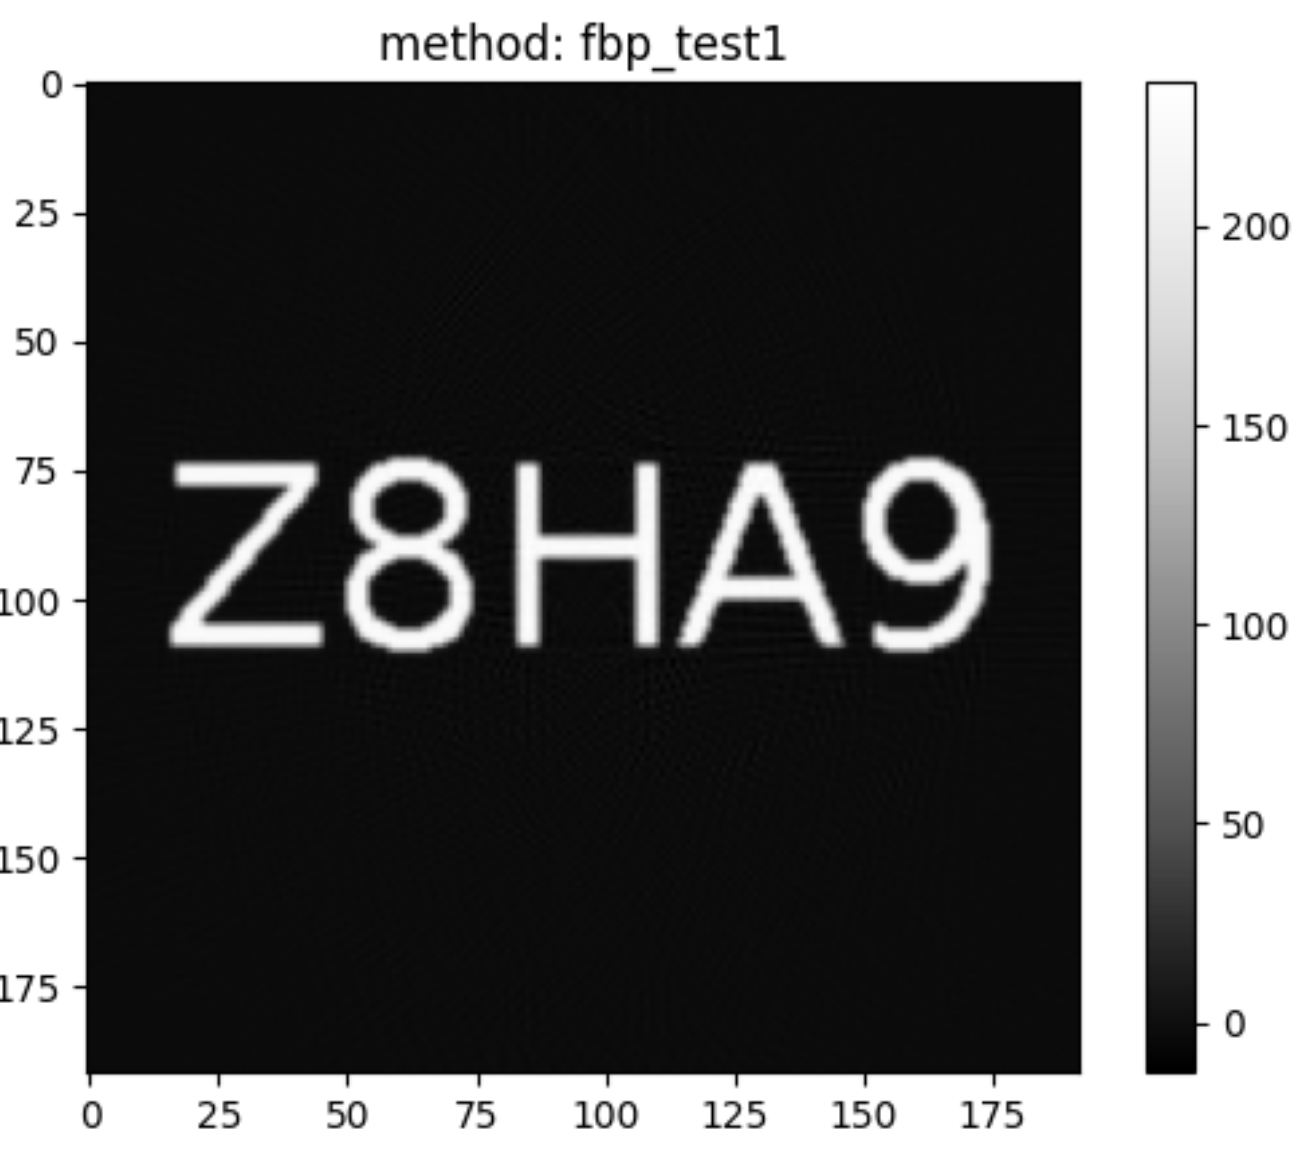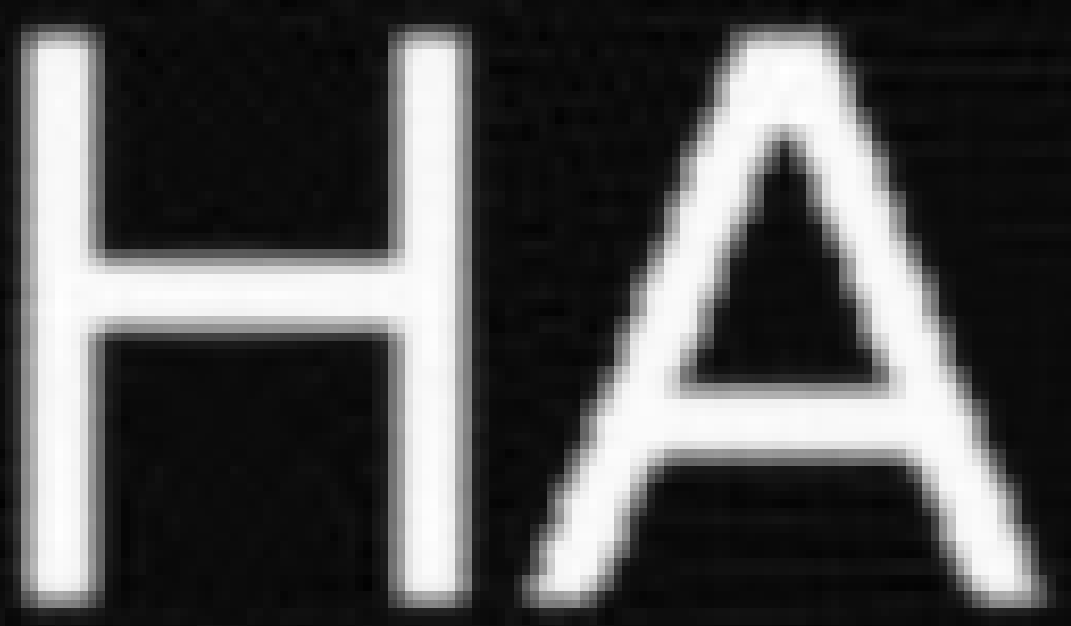

Le résultat avec interpolation est encore une fois beaucoup mieux que la question précédente. On remarque que le bruit est beaucoup moins présent et que les détails sont mieux définis. L'interpolation permet de mieux estimer les contributions des voxels qui ne tombent pas exactement sur les indices du détecteur, ce qui améliore la qualité de l'image reconstruite.

#### Question 6 ####

Pour cette question, on utilise une autre méthode, soit la reconstruction par le théorème de la coupe centrale. Cette méthode est implémentée dans la fonction reconFourierSlice(). Au lieu de procéder par rétroprojection spatiale, nous transformons chaque projection via une FFT 1D pour obtenir des segments radiaux dans le domaine de Fourier 2D. Ces segments sont ensuite positionnés dans une grille complexe selon l'angle correspondant, en utilisant une matrice de comptage pour normaliser les zones où les données se chevauchent. Une fois le domaine fréquentiel rempli, l'image finale est obtenue en appliquant une transformée de Fourier inverse 2D (IFFT). Le code utilisé est le suivant :

In [ ]:
def reconFourierSlice():
    [nbprj, angles, sinogram] = readInput()

    N = geo.nbpix
    M = geo.nbvox

    # conteneur pour la FFT du sinogramme
    SINOGRAM = np.zeros((M, M), 'complex')
    print(SINOGRAM.shape)
    #image reconstruite
    image = np.zeros((geo.nbvox, geo.nbvox))
    #votre code ici

    
    ##sinoX = np.arange(N) - N/2
    ##print(sinoX)
    sinoX = np.fft.fftshift(np.fft.fftfreq(N))*N
    #sinoX = np.fft.fftshift(np.fft.fftfreq(N))
    # 1. Préparer une grille de comptage pour normaliser
    counts = np.zeros_like(SINOGRAM, dtype=float)

    for a, th in enumerate(angles):
        sinoTF = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(sinogram[a,:])))
        
        for b, w in enumerate(sinoX):
            # Utilisation de th en radians si ce n'est pas déjà le cas
            kx = round((M)//2 + w * np.cos(th))
            ky = round((M)//2 + w * np.sin(th))

            if 0 <= ky < M and 0 <= kx < M:
                SINOGRAM[ky, kx] += sinoTF[b]
                counts[ky, kx] += 1


    # 2. Normalisation pour éviter l'accumulation au centre
    SINOGRAM[counts > 0] /= counts[counts > 0]

    # 3. Retour dans l'espace spatial
    image = SINOGRAM

    image = np.fft.ifftshift(np.fft.ifft2(image))
    image = np.fliplr(np.abs(image))  # abs avant tout
    # factor = geo.nbvox / image.shape[0]
    # image_resized = sc.ndimage.zoom(image, factor)
    util.saveImage(image, "fft_reconstructed")

On run et on obtient l'image suivante: 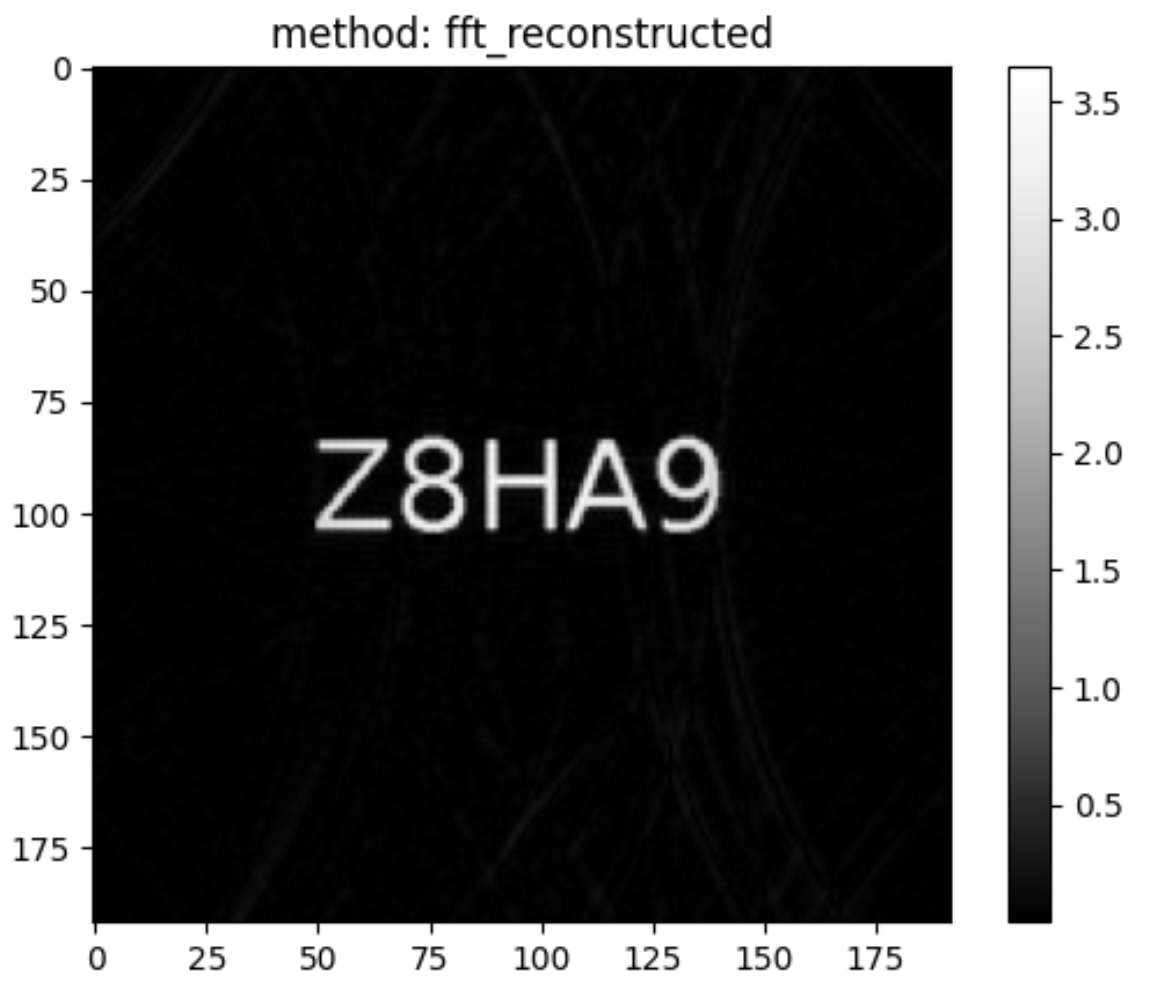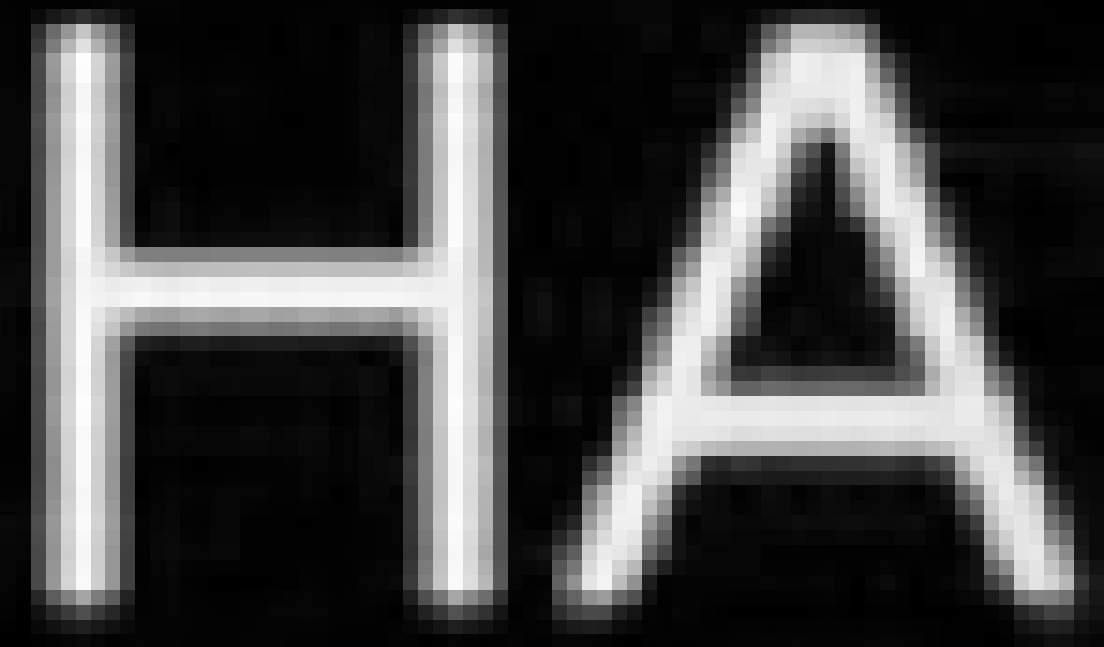

La reconstruction dans l'espace de Fourier est rapide et de bonne qualité, mais elle produit une image de qualité inférieure à la rétroprojection filtrée. On remarque l'apparition de motifs en arrière-plan et d'un grain plus prononcé. Cette méthode montre bien le compromis entre la vitesse de calcul et la fidélité de la reconstruction des textures fines.

#### Question 7 ####

Pour comparer les différentes méthodes, on va maintenant observer le sinogramme du patient selon les différentes méthodes de reconstruction: 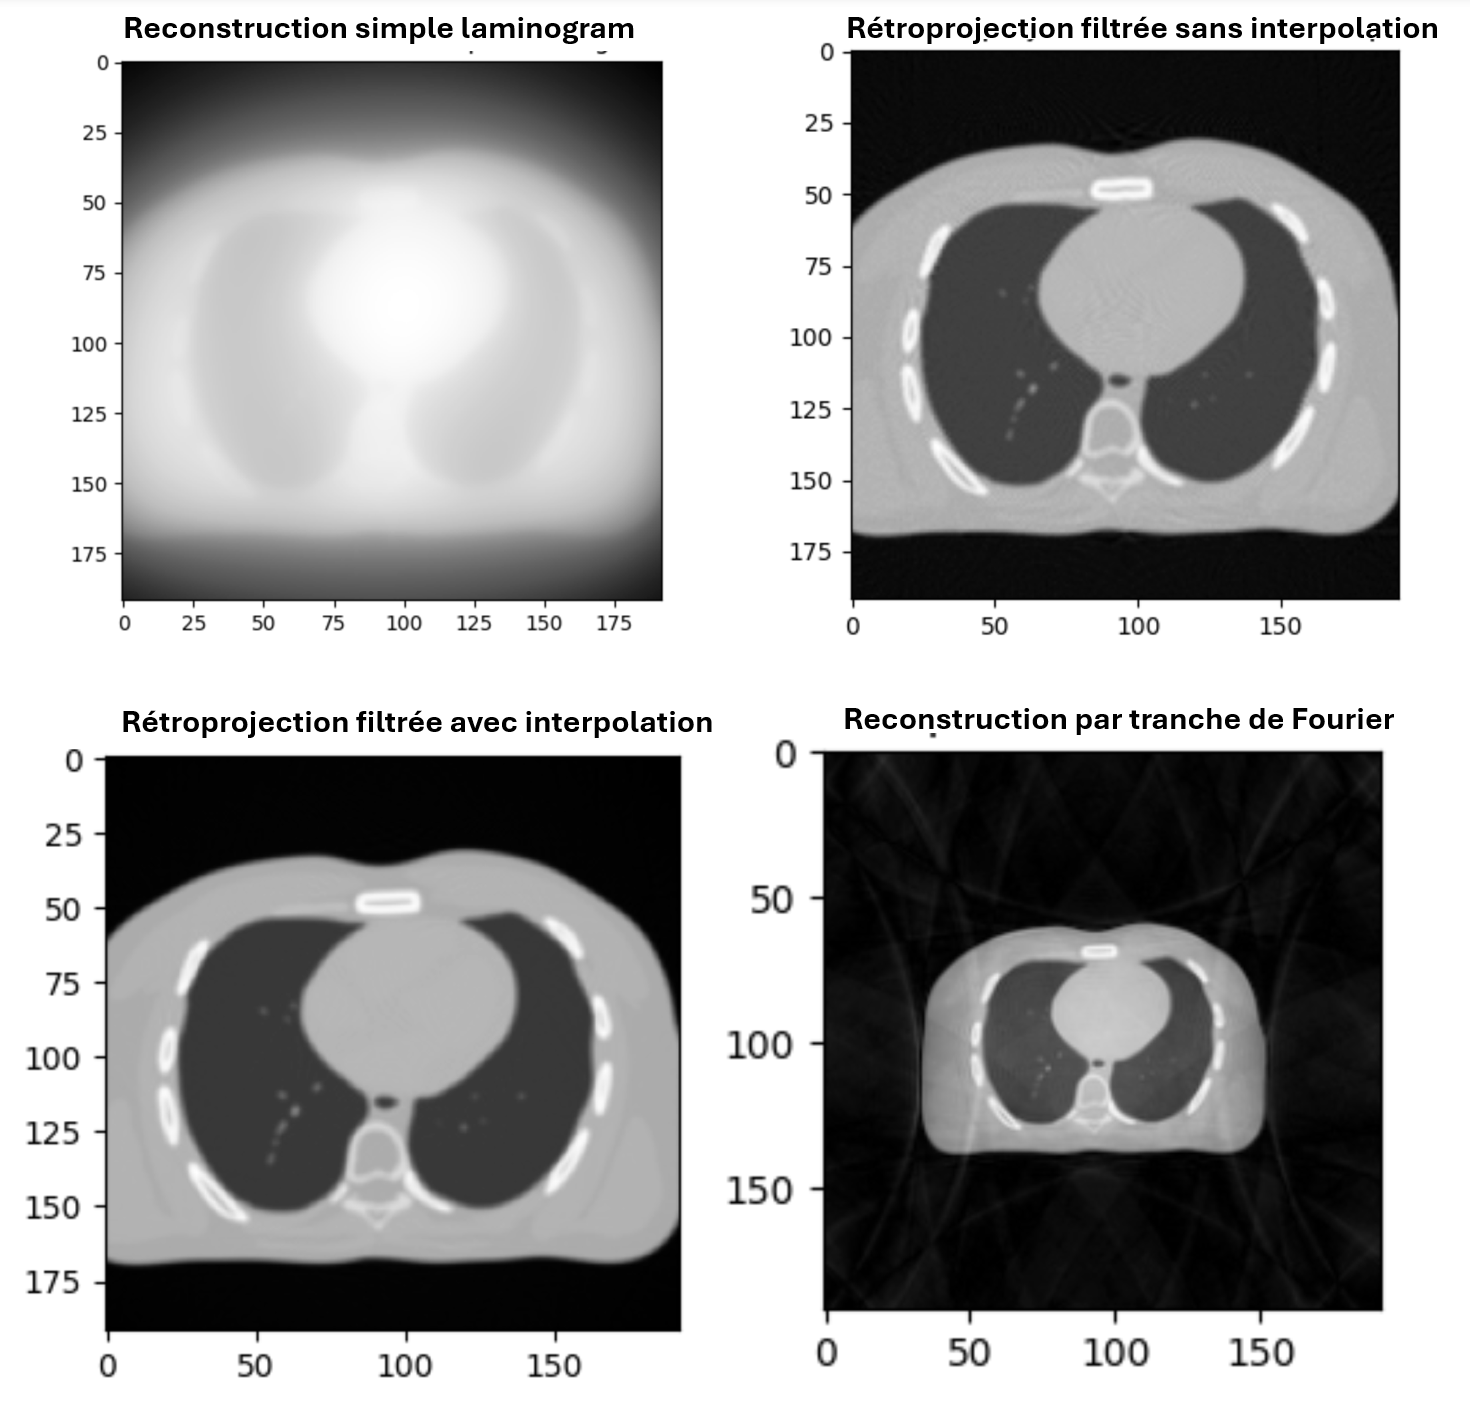

En comparant les différentes techniques, on constate que la rétroprojection simple est inutilisable en pratique à cause de son flou en $1/r$, alors que la rétroprojection filtrée (FBP) avec interpolation linéaire offre le meilleur équilibre entre netteté et réduction des artefacts. La méthode de Fourier, bien que performante sur le plan du temps de calcul, reste plus sensible au bruit et aux défauts d'échantillonnage fréquentiel. En conclusion, ce travail démontre que la qualité d'une image CT dépend non seulement de la précision géométrique de l'acquisition, mais surtout de l'application rigoureuse d'un filtrage approprié et d'une interpolation pour compenser la nature discrète des données numériques.

#### Question 8 ####

Dans cette étape, on teste l'effet du nombre de voxels (nbvox) et de leur taille (voxsize) sur l'image finale. En augmentant la densité de la grille, on améliore la résolution spatiale, ce qui rend les détails du fantôme beaucoup plus nets au prix d'un temps de calcul plus long. Depuis le début, les simulations sont faites avec une nombre de voxels assez grand, soit 192. Alors, pour vérifier l'hypothèse, on utilise des voxels plus grossiers et on observe la différence avec l'image précedente de reconstruction par tranche de Fourier. On utilise les paramètres suivants :

In [ ]:
nbvox = 96
voxsize = 0.4

Puis l'image générée est la suivante pour le patient. 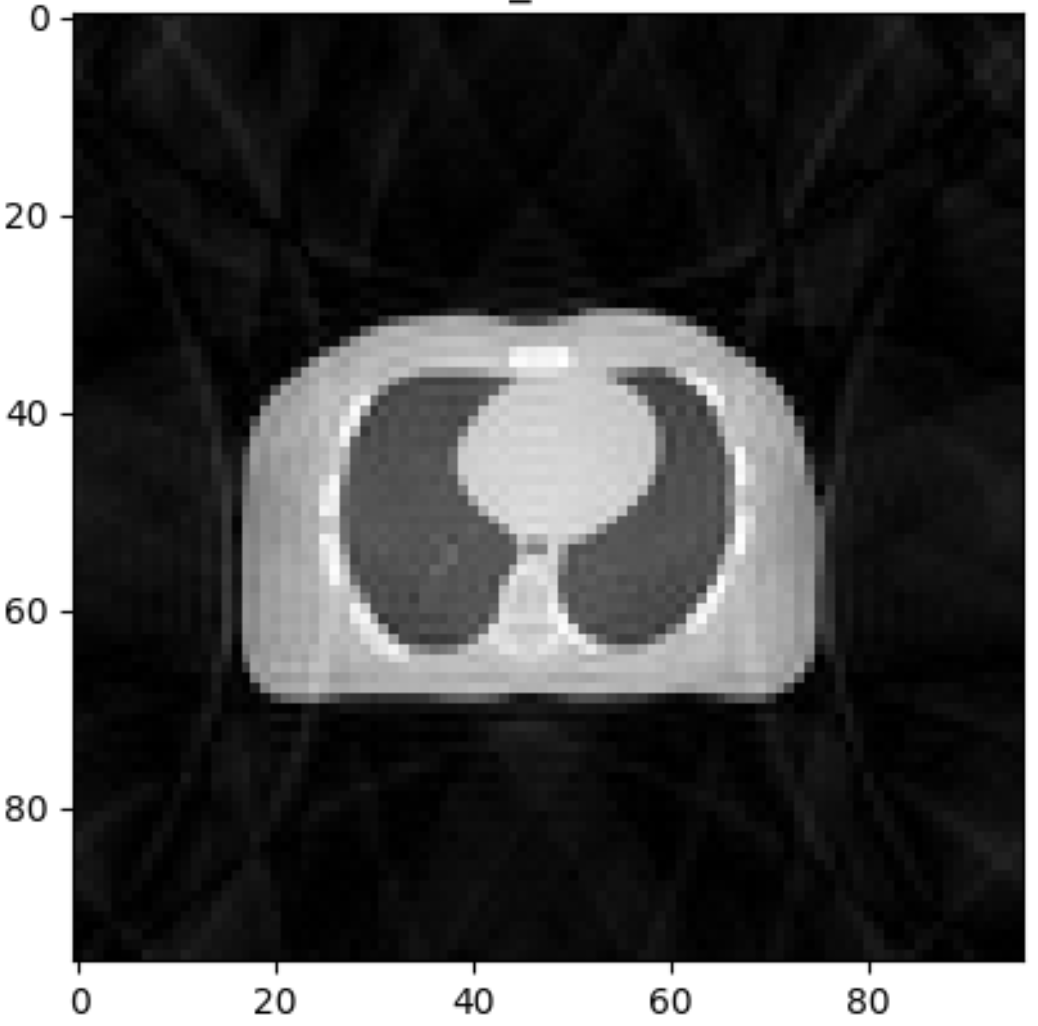

On remarque directement que l'image est beaucoup moins nette qu'avec les paramètres initiaux: nbvox = 192 et voxsize = 0.2. Cette image n'est donc clairement pas assez bonne pour poser un diagnostic médical. Par contre, l'image avec plus de voxels par reconstruction par tranche de Fourier est probablement assez bonne pour poser un diagnostique. Cette image est a déja été montrée au numéro 7, mais est représenté encore ici:
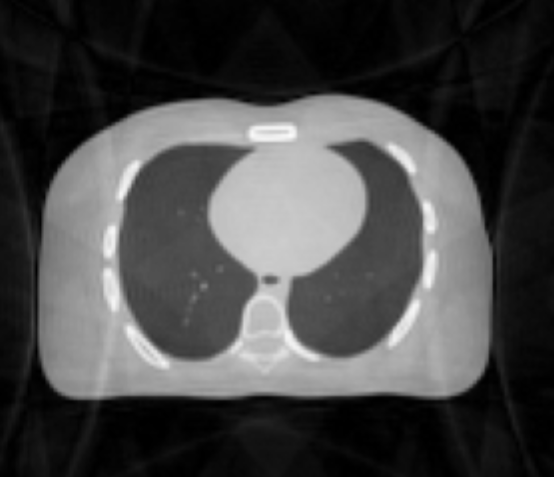

Cette image est bien plus acceptable car elle permet de distinguer des petites structures qui resteraient invisibles ou floues sur une grille moins dense.

#### Question 9 ####

Au niveau de la vitesse, la méthode de Fourier est la plus performante avec un temps de seulement 0.84 s, car elle utilise des raccourcis mathématiques pour créer l'image très rapidement. Pour la rétroprojection filtrée, qui a pris 1.22 s, on a réussi à gagner beaucoup de temps en évitant de calculer chaque petit point de l'image un par un. À la place, on traite de gros blocs de données d'un seul coup, ce qui évite au programme de faire des répétitions inutiles. C'est une énorme différence par rapport au laminogramme qui a duré 82 s ; celui-ci est beaucoup plus lent car il doit répéter les mêmes étapes des milliers de fois sans raccourci, ce qui montre bien que la façon d'écrire le code est aussi importante que la méthode mathématique choisie.

#### Question 10 - BONUS ####

Dans cette section, on améliore la méthode de la tranche de Fourier en remplaçant l'arrondi au plus proche voisin par une interpolation bi-linéaire. Au lieu de déposer la valeur d'une projection sur un seul point de la grille, la fonction reconFourierSlice() distribue maintenant l'information sur les quatre voisins les plus proches, proportionnellement à leur distance. Le code utilisé est le suivant :

In [ ]:
def reconFourierSlice():
    [nbprj, angles, sinogram] = readInput()

    N = geo.nbpix
    M = geo.nbvox

    # Conteneur pour la FFT du sinogramme et grille de poids
    SINOGRAM = np.zeros((M, M), dtype='complex')
    counts = np.zeros((M, M), dtype=float)
    
    # Coordonnées fréquentielles du sinogramme
    sinoX = np.fft.fftshift(np.fft.fftfreq(N)) * N

    for a, th in enumerate(angles):
        # FFT 1D de la projection
        sinoTF = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(sinogram[a,:])))
        
        for b, w in enumerate(sinoX):
            # Coordonnées flottantes dans la grille de Fourier
            kx_f = (M/2) + w * np.cos(th)
            ky_f = (M/2) + w * np.sin(th)

            # Identification des 4 voisins (indices entiers)
            x0 = int(np.floor(kx_f))
            y0 = int(np.floor(ky_f))
            x1, y1 = x0 + 1, y0 + 1

            # Calcul des distances (poids)
            dx = kx_f - x0
            dy = ky_f - y0

            # Distribution de la valeur sur les 4 voisins
            # Format: (x, y, poids)
            neighbors = [
                (x0, y0, (1 - dx) * (1 - dy)),
                (x1, y0, dx * (1 - dy)),
                (x0, y1, (1 - dx) * dy),
                (x1, y1, dx * dy)
            ]

            for nx, ny, weight in neighbors:
                if 0 <= nx < M and 0 <= ny < M:
                    SINOGRAM[ny, nx] += sinoTF[b] * weight
                    counts[ny, nx] += weight

    # Normalisation par les poids accumulés
    SINOGRAM[counts > 0] /= counts[counts > 0]

    # Retour dans l'espace spatial
    image = np.fft.ifftshift(np.fft.ifft2(np.fft.ifftshift(SINOGRAM)))
    image = np.fliplr(np.abs(image))
    
    util.saveImage(image, "Reconstruction_Fourier_Bilineaire")

On roule le code et on obtient les images suivantes pour le patient et le password: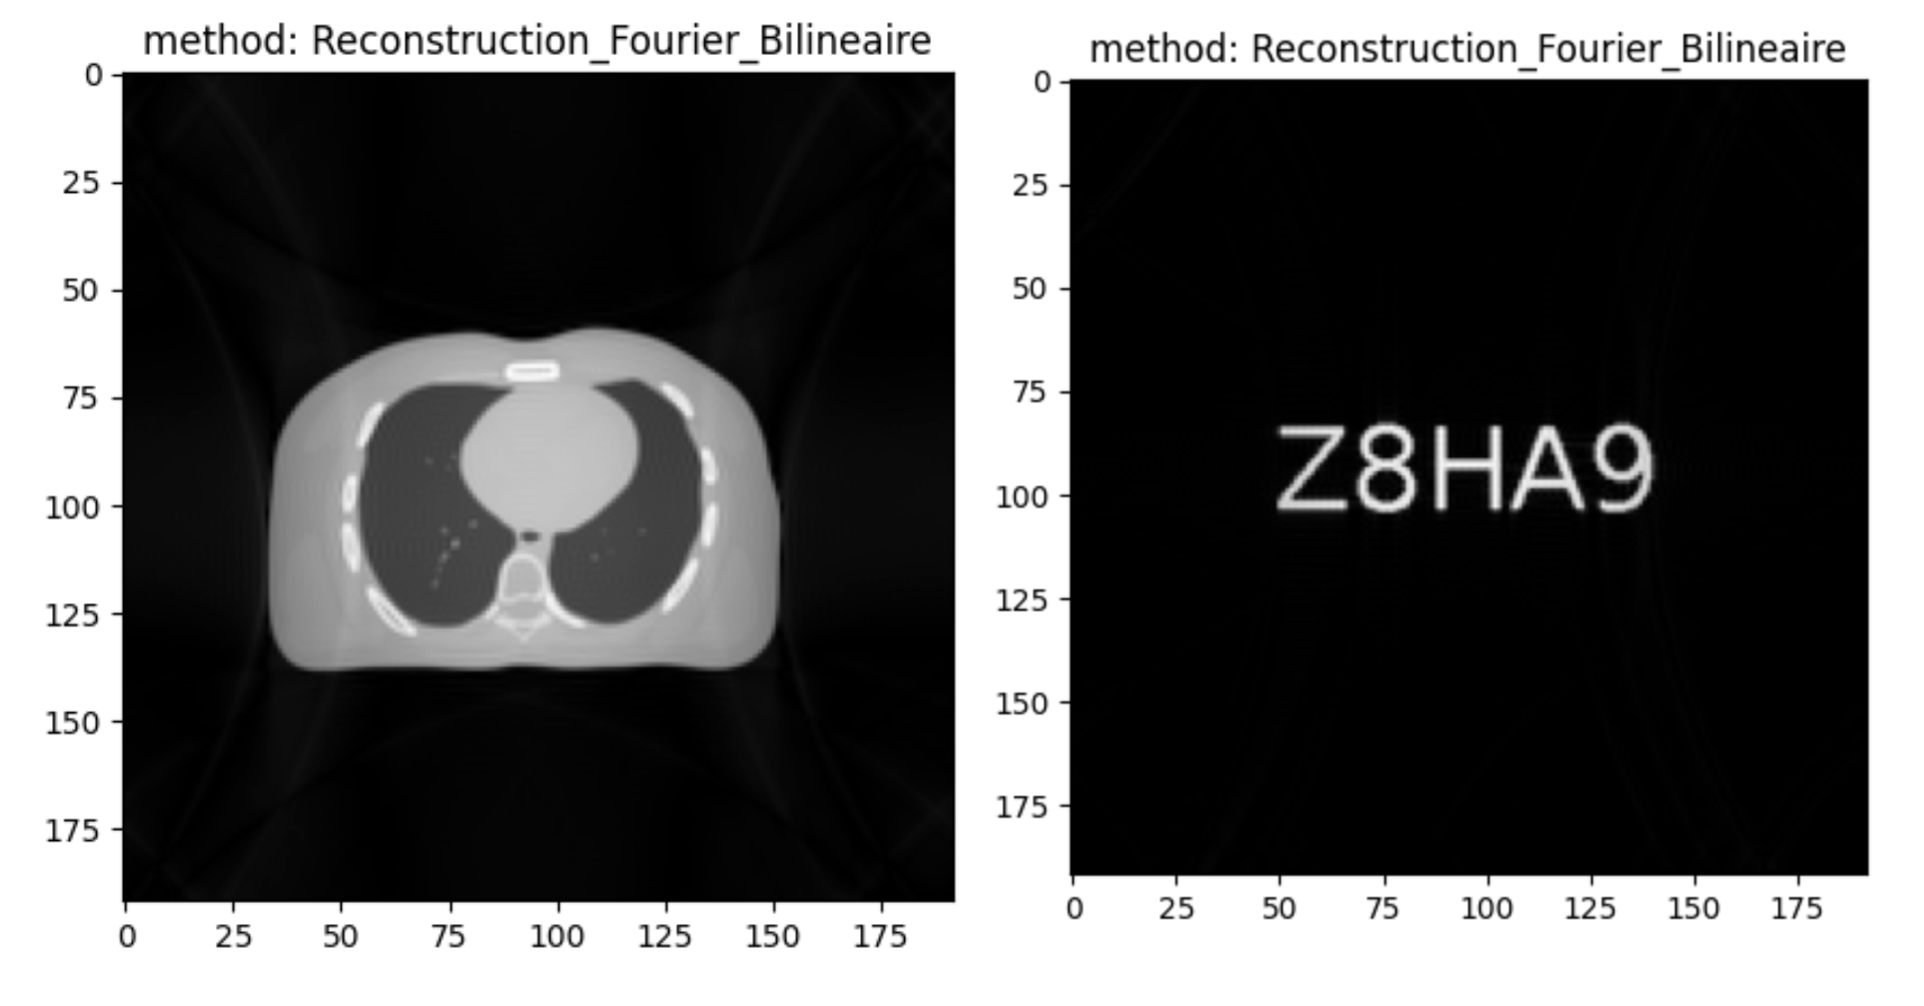

On remarque que la qualité est la meilleure obtenue jusqu'à présent. Les contours sont très bien définis, et le bruit de fond est très très faible. On note encore quelques légers motifs en arrière-plan, mais ils sont très légers.